In [13]:
import pandas as pd

# 예를 들어 원본 파일이 크다면
df = pd.read_csv('data/유통공사_도매시장_상추_20180101-20250531.csv', encoding='cp949')

# 상위 1000개 샘플만 추출
sample_df = df.sample(n=10000, random_state=42)

# 저장
sample_df.to_csv('상추_샘플.csv', index=False, encoding='cp949')


C:\Users\Admin\AppData\Local\Temp\ipykernel_8124\3981764554.py:4: DtypeWarning: Columns (9,17) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/유통공사_도매시장_상추_20180101-20250531.csv', encoding='cp949')


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

# 한글 폰트 (Windows 기준)
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# 파일 읽기
df = pd.read_csv('상추_샘플.csv', encoding='cp949')
print(df.shape)
print(df.head())


(10000, 28)
    avgprc   corp_cd    corp_nm  gds_lclsf_cd gds_lclsf_nm  gds_mclsf_cd  \
0   5500.0  21000901      동부청과㈜            10         엽경채류             5   
1   9000.0  21000103      항도청과㈜            10         엽경채류             5   
2   1600.0  25000101    농협대전(공)            10         엽경채류             5   
3   9000.0  23000303  인천원협삼산(공)            10         엽경채류             5   
4  12000.0  11000102    농협가락(공)            10         엽경채류             5   

  gds_mclsf_nm  gds_sclsf_cd gds_sclsf_nm grd_cd  ...     sz_nm     totprc  \
0           상추            99         기타상추     12  ...         .    55000.0   
1           상추             2          적상추     11  ...       11개  1170000.0   
2           상추             2          적상추     10  ...         .    11200.0   
3           상추             4          적포기     11  ...  1개(내,뿌리)    45000.0   
4           상추             1          청상추     11  ...         .   120000.0   

   trd_clcln_ymd  trd_se unit_cd unit_nm unit_qty unit_tot_qty

In [17]:
print(df.columns.tolist())


['avgprc', 'corp_cd', 'corp_nm', 'gds_lclsf_cd', 'gds_lclsf_nm', 'gds_mclsf_cd', 'gds_mclsf_nm', 'gds_sclsf_cd', 'gds_sclsf_nm', 'grd_cd', 'grd_nm', 'hgprc', 'lwprc', 'pkg_cd', 'pkg_nm', 'plor_cd', 'plor_nm', 'sz_cd', 'sz_nm', 'totprc', 'trd_clcln_ymd', 'trd_se', 'unit_cd', 'unit_nm', 'unit_qty', 'unit_tot_qty', 'whsl_mrkt_cd', 'whsl_mrkt_nm']


In [16]:
# 단가 분포
plt.figure(figsize=(8, 4))
sns.histplot(df['단가'], bins=50, kde=True)
plt.title('단가 분포')
plt.show()

# 등급별
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='등급이름', y='단가')
plt.title('등급별 단가 분포')
plt.show()

# 산지별
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='산지이름', y='단가')
plt.xticks(rotation=45)
plt.title('산지별 단가 분포')
plt.show()


KeyError: '단가'

<Figure size 800x400 with 0 Axes>

In [6]:
# 날짜 컬럼 변환
date_col = '날짜(YYYY-MM-DD)'

if date_col in df.columns and not pd.api.types.is_datetime64_any_dtype(df[date_col]):
    df[date_col] = pd.to_datetime(df[date_col])
    df['연도'] = df[date_col].dt.year
    df['월'] = df[date_col].dt.month
    df['일'] = df[date_col].dt.day

print(df[['연도', '월', '일']].head())


     연도   월   일
0  2025   2   6
1  2019   8   7
2  2018   7  19
3  2019   8   7
4  2024  12  14


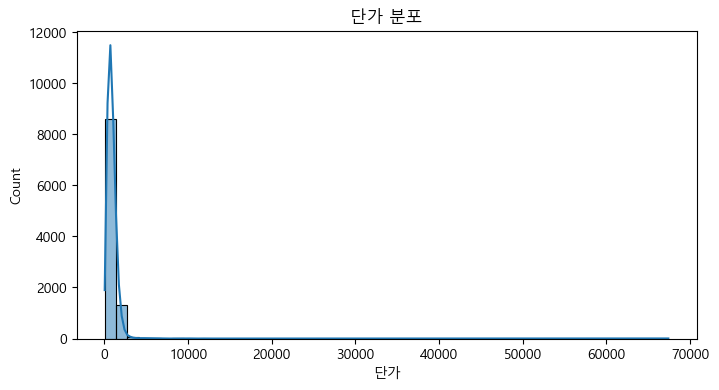

In [7]:
if '단가' not in df.columns:
    df = df[df['단위총물량(kg)'] > 0].copy()
    df['단가'] = df['총가격(원)'] / df['단위총물량(kg)']
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(subset=['단가'], inplace=True)

plt.figure(figsize=(8, 4))
sns.histplot(df['단가'], bins=50, kde=True)
plt.title('단가 분포')
plt.show()


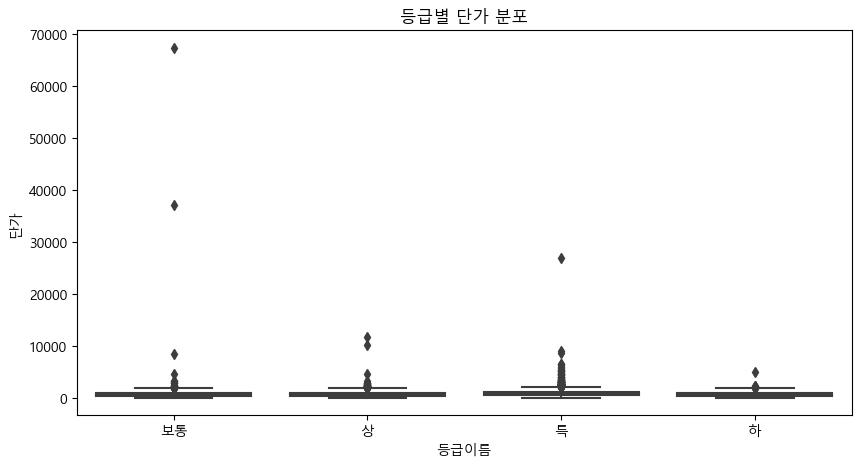

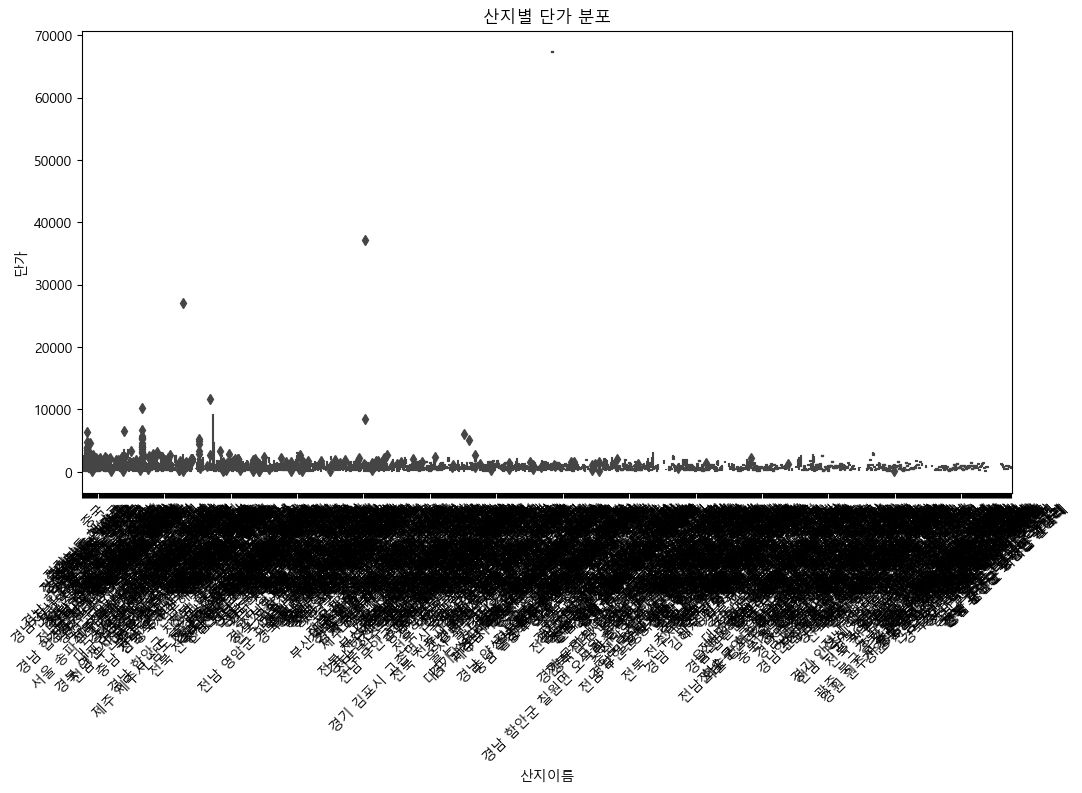

In [8]:
# 등급별
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='등급이름', y='단가')
plt.title('등급별 단가 분포')
plt.show()

# 산지별
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='산지이름', y='단가')
plt.xticks(rotation=45)
plt.title('산지별 단가 분포')
plt.show()


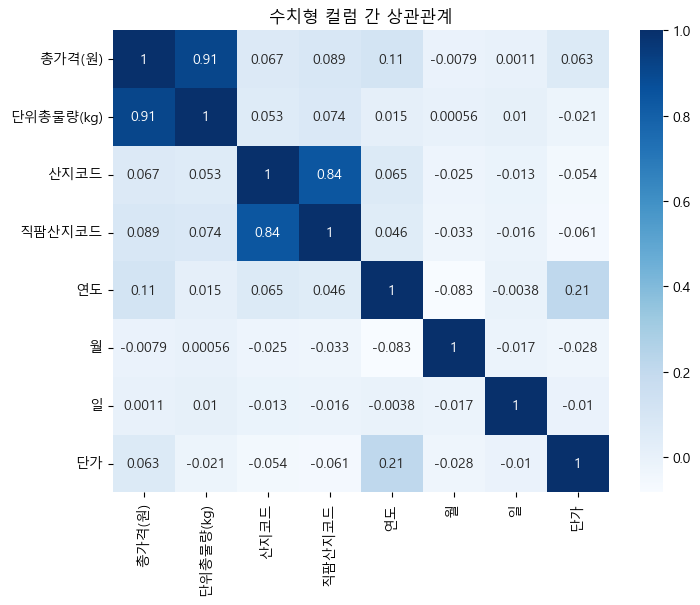

In [9]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='Blues')
plt.title('수치형 컬럼 간 상관관계')
plt.show()


In [10]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

# 사용 컬럼
features = ['등급이름', '산지이름', '직팜산지이름', '산지코드', '직팜산지코드', '연도', '월', '일']
target = '단가'

df_model = df[features + [target]].dropna()
X = df_model[features]
y = df_model[target]

categorical_features = ['등급이름', '산지이름', '직팜산지이름']
numerical_features = ['연도', '월', '일']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])

print("모델 학습 중...")
model_pipeline.fit(X, y)
print("모델 학습 완료!")


모델 학습 중...
모델 학습 완료!


변환된 X shape: (10000, 2137)
Feature 이름 개수: 2137


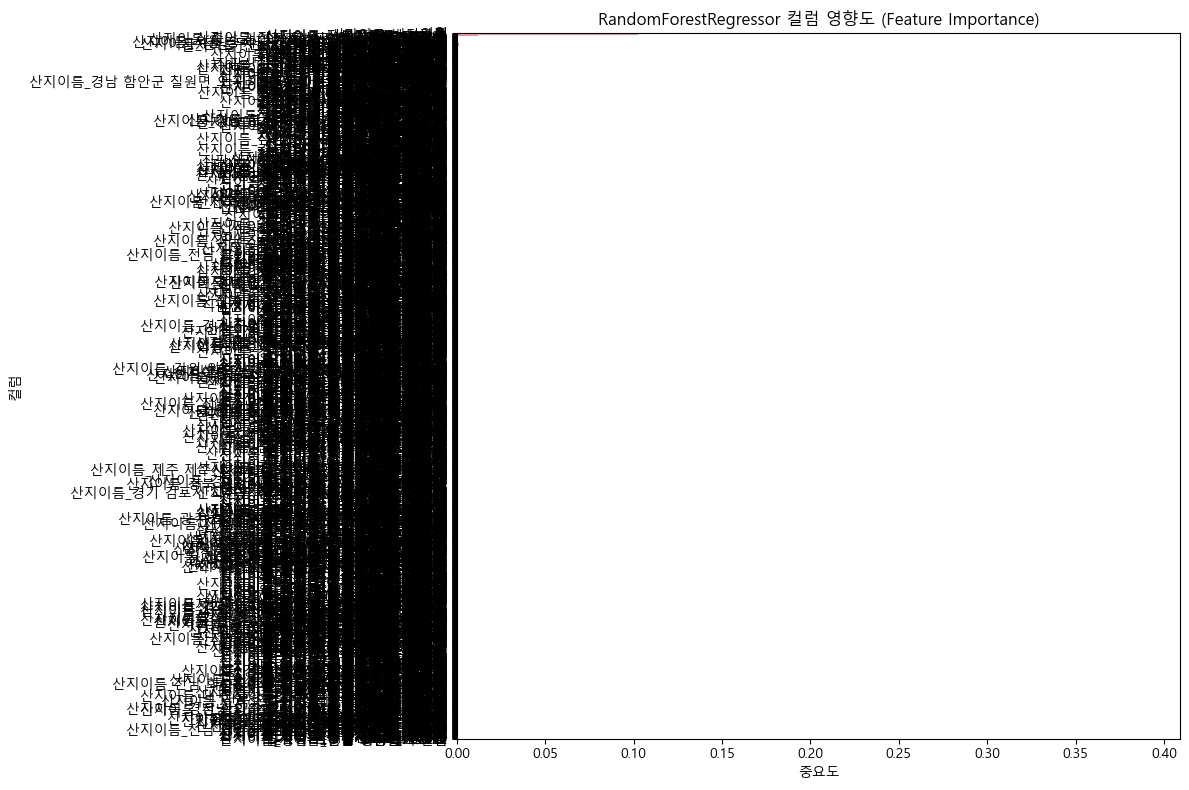

              Feature  Importance
419         산지이름_네덜란드    0.389590
2134               연도    0.158086
2136                일    0.130092
2135                월    0.102475
1535      산지코드_580090    0.021282
784   산지이름_전북 정읍시 농소동    0.012957
2              등급이름_특    0.011709
1075      산지코드_138160    0.009321
476   산지이름_서울 송파구 가락동    0.008305
1508      산지코드_570600    0.008278


In [12]:
# 혹시 산지코드, 직팜산지코드를 범주형으로 취급하려면 추가
categorical_features = ['등급이름', '산지이름', '직팜산지이름', '산지코드', '직팜산지코드']
numerical_features = ['연도', '월', '일']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])

model_pipeline.fit(X, y)

# ✅ 변환된 X의 feature 이름 다시 가져오기
ohe_feature_names = model_pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features)
all_feature_names = list(ohe_feature_names) + numerical_features

# ✅ 변환된 X shape와 feature 이름 개수 일치 확인
X_transformed = model_pipeline.named_steps['preprocessor'].transform(X)
print("변환된 X shape:", X_transformed.shape)
print("Feature 이름 개수:", len(all_feature_names))

# ✅ 이름과 중요도 배열 길이 확인 후 DataFrame 생성
importances = model_pipeline.named_steps['regressor'].feature_importances_

if X_transformed.shape[1] == len(all_feature_names):
    feature_importances_df = pd.DataFrame({
        'Feature': all_feature_names,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)

    plt.figure(figsize=(12, 8))
    sns.barplot(x='Importance', y='Feature', data=feature_importances_df)
    plt.title('RandomForestRegressor 컬럼 영향도 (Feature Importance)')
    plt.xlabel('중요도')
    plt.ylabel('컬럼')
    plt.tight_layout()
    plt.show()

    print(feature_importances_df.head(10))
else:
    print("⚠️ Feature 이름 개수와 변환된 X 컬럼 개수가 일치하지 않습니다!")
